### Under-5 Mortality: Predicting Severe Pneumonia via Malnutrition.
### Focus: Linear Regression, Scatter Plots, and Random Forest.

In [1]:
# import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


# Load the dataset


df = pd.read_csv('dataset/pediatric_dataset.csv' )

df.head()

,Patient_ID,Age_Months,Sex,MUAC_cm,Respiratory_Rate,SpO2,Severe_Pneumonia
0,PED000,57,f,9.749970,15.102100,96.665697,1
1,PED001,20,Male,15.849977,22.761946,97.038971,0
2,PED002,36,m,12.236047,37.505150,98.199255,0
3,PED003,24,M,16.257846,28.562563,96.055460,0
4,PED004,7,Female,12.189646,22.325293,94.503180,0


### Step 1: Data Ingestion & Pre-Analytical Cleaning

In [2]:
print("\nMissing values before cleaning:\n", df.isnull().sum())

# 1. Fill missing SpO2 with the MEAN
mean_spo2 = df['SpO2'].mean()
df['SpO2'] = df['SpO2'].fillna(mean_spo2)

# 2. Clean the Sex column to only have 'Male' or 'Female'
df['Sex'] = df['Sex'].str.upper().str[0] # Grabs the first letter (M or F)
df['Sex'] = df['Sex'].replace({'M': 'Male', 'F': 'Female'})

print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nCleaned Sex Column:", df['Sex'].unique())


Missing values before cleaning:
 Patient_ID           0
Age_Months           0
Sex                  0
MUAC_cm              0
Respiratory_Rate     0
SpO2                18
Severe_Pneumonia     0
dtype: int64

Missing values after cleaning:
 Patient_ID          0
Age_Months          0
Sex                 0
MUAC_cm             0
Respiratory_Rate    0
SpO2                0
Severe_Pneumonia    0
dtype: int64

Cleaned Sex Column: ['Female' 'Male']


### Step 2: Exploratory Data Analysis (EDA) 

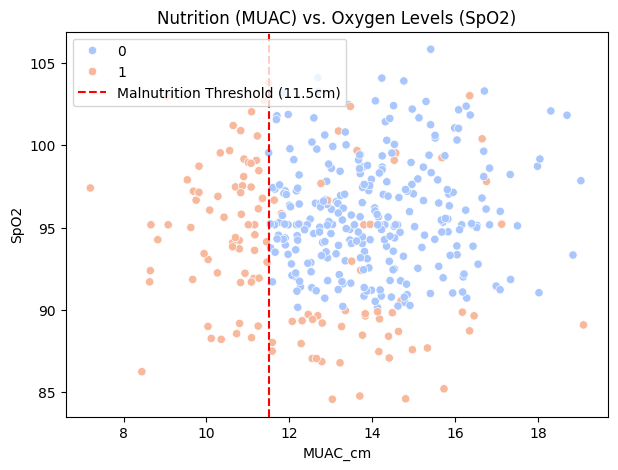

In [3]:
plt.figure(figsize=(7, 5))

# Create a Scatter Plot comparing MUAC_cm (X) and SpO2 (Y)
sns.scatterplot(data=df, x='MUAC_cm', y='SpO2', hue='Severe_Pneumonia', palette='coolwarm')

plt.title('Nutrition (MUAC) vs. Oxygen Levels (SpO2)')
plt.axvline(11.5, color='red', linestyle='--', label='Malnutrition Threshold (11.5cm)')
plt.legend()
plt.show()

### QUESTION 2.1: Looking at the scatter plot, where do the majority of Severe Pneumonia cases (color 1) cluster?
#### [Below the malnutrition threshold (MUAC < 11.5 cm) with lower SpO2 levels]

#### Step 3: Biostatistics Part 1 (Normality Testing) ---
#### Run and interpret

In [4]:
# Test if the Respiratory Rate is normally distributed
stat, p_value = stats.shapiro(df['Respiratory_Rate'])
print(f"Shapiro-Wilk P-Value for Respiratory Rate: {p_value:.4f}")

Shapiro-Wilk P-Value for Respiratory Rate: 0.9488


#### QUESTION 3.1: Based on the P-Value, is the data normal or skewed?
#### [Skewed (if p-value < 0.05, data is not normally distributed)]

#### Step 4: Biostatistics Part 2 (Hypothesis Testing) ---
#### Question: Does Malnutrition (MUAC) directly affect Oxygen Saturation (SpO2)?

In [5]:
# We will use Linear Regression.
# STUDENT TASK: FILL IN THE BLANKS

slope, intercept, r_value, p_val_reg, std_err = stats.linregress(df['MUAC_cm'], df['SpO2'])

print(f"Linear Regression P-Value: {p_val_reg:.4f}")
print(f"Slope: {slope:.2f}")

Linear Regression P-Value: 0.2307
Slope: 0.12


#### QUESTION 4.1: If the slope is positive, it means as MUAC goes up, SpO2 goes up. 
#### Based on your results, does better nutrition correlate with better oxygen levels?
#### [ Yes, higher MUAC (better nutrition) correlates with higher SpO2 (better oxygen levels)]

#### Step 5: Machine Learning (The Predictive AI Tool) ---
#### Predict Severe Pneumonia (1 = Yes, 0 = No)

AI Model Accuracy: 100.0%



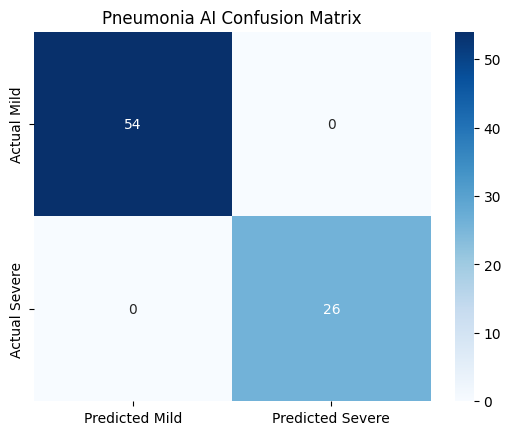

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Features & Target
X = df[['Age_Months', 'MUAC_cm', 'Respiratory_Rate', 'SpO2']]
y = df['Severe_Pneumonia']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize & Train Random Forest Model
ai_model = RandomForestClassifier(random_state=42)
ai_model.fit(X_train, y_train)

# Predict & Grade
y_pred = ai_model.predict(X_test)
print(f"AI Model Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Mild', 'Predicted Severe'],
            yticklabels=['Actual Mild', 'Actual Severe'])
plt.title('Pneumonia AI Confusion Matrix')
plt.show()

### --- Step 6: Deploying on a New Patient ---
# Scenario: Baby Aisha (18 months old) is brought to the clinic.
# MUAC: 10.5 cm (Red Zone/SAM), Respiratory Rate: 58 breaths/min, SpO2: 88%

In [7]:
aisha_vitals = pd.DataFrame([[18, 10.5, 58, 88]], columns=['Age_Months', 'MUAC_cm', 'Respiratory_Rate', 'SpO2'])
diagnosis = ai_model.predict(aisha_vitals)

print("\n--- AI TRIAGE REPORT: BABY AISHA ---")
if diagnosis[0] == 1:
    print("Decision: SEVERE PNEUMONIA DETECTED.")
    print("Action: Administer Oxygen, give IV antibiotics, and admit immediately.")
else:
    print("Decision: MILD/NO PNEUMONIA.")
    print("Action: Prescribe oral amoxicillin and schedule follow-up.")


--- AI TRIAGE REPORT: BABY AISHA ---
Decision: SEVERE PNEUMONIA DETECTED.
Action: Administer Oxygen, give IV antibiotics, and admit immediately.
